# Análisis Exploratorio de Datos (EDA)
# 1 INTRODUCCIÓN

En este notebook se realiza un análisis exploratorio inicial del dataset **MIMIC-IV** utilizado en este trabajo. El objetivo es comprender la estructura de las tablas seleccionadas, estudiar la distribución de las variables principales y detectar posibles problemas de calidad de los datos que deban tenerse en cuenta en las fases posteriores de preprocesado y modelado.

El análisis se centra en cinco tablas principales:

- `patients`
- `admissions`
- `diagnoses_icd`
- `procedures_icd`
- `prescriptions`

Además de ofrecer una visión descriptiva del conjunto de datos, este EDA permite identificar patrones relevantes para el problema de estudio: la **predicción del reingreso hospitalario a 30 días**. Por ello, las observaciones obtenidas aquí servirán para justificar decisiones posteriores relacionadas con la selección de variables, el tratamiento de valores ausentes y la construcción de la variable objetivo.

En esta sección inicial, cargaremos los datasets del MIMIC-IV utilizando la configuración definida en `src/config.py`. Esto incluye las tablas de pacientes, admisiones, diagnósticos y procedimientos. Posteriormente, se extraen lastablas en variables  para poder trabajar con ellas.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.config import FILES
from src.data.load import load_multiple_datasets

A continuación se cargan los datasets desde los archivos definidos en la configuración mediante la función `load_multiple_datasets`. Los datos se almacenan inicialmente en un diccionario para facilitar su organización y acceso.

In [2]:
# Cargamos los datasets principales (patients, admissions, diagnoses, procedures)
# La tabla prescriptions se carga por separado con una muestra por su gran tamaño
files_eda = {k: v for k, v in FILES.items() if k != "prescriptions"}
datasets = load_multiple_datasets(files_eda)

# Prescriptions supera la memoria disponible al cargarse completa.
# Para el EDA se utiliza una muestra de 500.000 filas, suficiente para
# analizar distribuciones y frecuencias de fármacos.
print("Loading prescriptions (muestra)...")
try:
    datasets["prescriptions"] = pd.read_csv(
        FILES["prescriptions"], nrows=500_000, low_memory=False
    )
    print(f"  prescriptions: {len(datasets['prescriptions']):,} filas cargadas")
except Exception as e:
    print(f"  prescriptions no disponible: {e}")
    datasets["prescriptions"] = pd.DataFrame(
        columns=["subject_id", "hadm_id", "drug", "drug_type"]
    )

Loading patients...
Loading admissions...
Loading diagnoses...
Loading procedures...
Loading prescriptions (muestra)...
  prescriptions: 500,000 filas cargadas


Una vez cargados los datos, se crean variables locales para trabajar de forma más cómoda con cada tabla por separado:

- `patients`
- `admissions`
- `diagnoses`
- `procedures`
- `prescriptions`

Esto permite operar directamente con cada `DataFrame` sin necesidad de referirse continuamente al diccionario original.

# 2 CARGA DE LOS DATOS

In [3]:
patients = datasets["patients"]
admissions = datasets["admissions"]
diagnoses = datasets["diagnoses"]
procedures = datasets["procedures"]
prescriptions = datasets["prescriptions"]

In [4]:
patients.shape
#admissions.shape
#diagnoses.shape
#procedures.shape
#prescriptions.shape


(364627, 6)

# 3 Estructura general del dataset


Antes de profundizar en variables concretas, se realiza una inspección general de las tablas seleccionadas. Esta revisión permite conocer su tamaño, formato y principales campos, así como detectar desde el inicio posibles diferencias entre tablas o problemas de tipado.

In [ ]:
patients.head()
#admissions.head()
#diagnoses.head()
#procedures.head()
#prescriptions.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


gender no tiene valores nulos entonces no hace falta

In [ ]:
#patients.info()
admissions.info()
#diagnoses.info()
#rocedures.info()
#prescriptions.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   admittime             546028 non-null  object
 3   dischtime             546028 non-null  object
 4   deathtime             11790 non-null   object
 5   admission_type        546028 non-null  object
 6   admit_provider_id     546024 non-null  object
 7   admission_location    546027 non-null  object
 8   discharge_location    396210 non-null  object
 9   insurance             536673 non-null  object
 10  language              545253 non-null  object
 11  marital_status        532409 non-null  object
 12  race                  546028 non-null  object
 13  edregtime             379240 non-null  object
 14  edouttime             379240 non-null  object
 15  hospital_expire_f

### Número de pacientes únicos

In [5]:
#Número de pacientes únicos
num_patients=patients["subject_id"].nunique()
print("Número de pacientes únicos:", num_patients)


Número de pacientes únicos: 364627


### Número de hospitalizaciones únicas

In [6]:
#Número de hospitalizaciones únicas
num_admissions=admissions["hadm_id"].nunique()
print("Número de hospitalizaciones únicas:", num_admissions)

Número de hospitalizaciones únicas: 546028


### Hospitalizaciones por paciente

In [7]:

#Vemos la distribución del número de hospitalizaciones por paciente
admissions_per_patient = admissions.groupby("subject_id")["hadm_id"].count()
admissions_per_patient.describe()
print("Número de hospitalizaciones por paciente:", admissions_per_patient.mean())

Número de hospitalizaciones por paciente: 2.4436031004421532


**Gráfico 1.** Distribución general de hospitalizaciones por paciente (GENERAL)

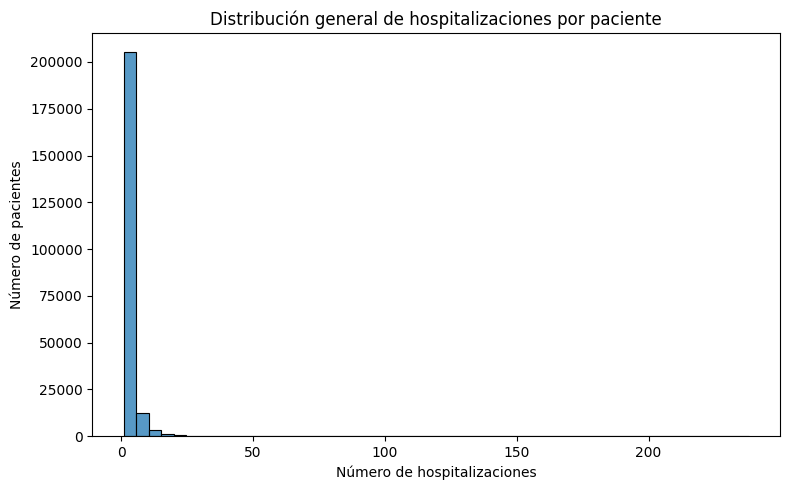

In [8]:
#grafico 1 distribucción general

plt.figure(figsize=(8,5))

sns.histplot(admissions_per_patient, bins=50)

plt.title("Distribución general de hospitalizaciones por paciente")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Número de pacientes")

plt.tight_layout()
plt.savefig("../results/eda_01_hospitalizaciones_por_paciente.png", dpi=150, bbox_inches="tight")
plt.show()

La mayoría de los pacientes presentan una única hospitalización, mientras que un número reducido de pacientes 
presenta múltiples ingresos hospitalarios.


**Gráfico 2.** Distribución de hospitalizaciones por paciente con mayor nivel de detalle.

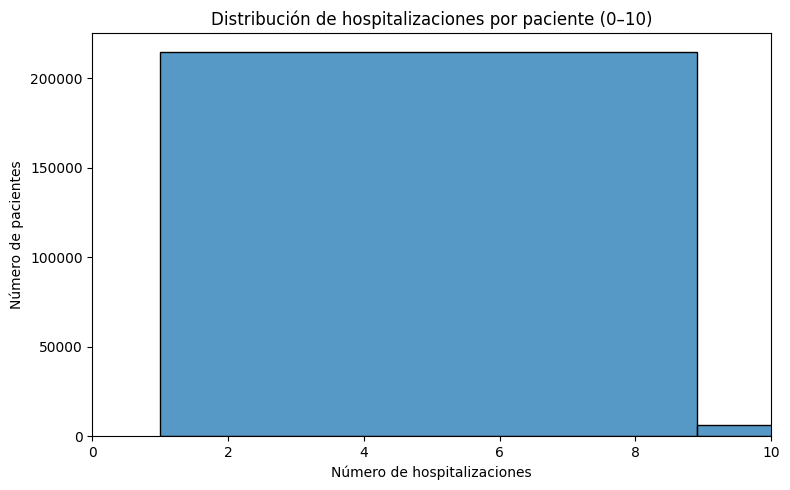

In [9]:
#grafico 2 para verlo más en detalle
plt.figure(figsize=(8,5))

sns.histplot(admissions_per_patient, bins=30)

plt.xlim(0,10)

plt.title("Distribución de hospitalizaciones por paciente (0–10)")
plt.xlabel("Número de hospitalizaciones")
plt.ylabel("Número de pacientes")

plt.tight_layout()
plt.savefig("../results/eda_02_hospitalizaciones_por_paciente_detalle.png", dpi=150, bbox_inches="tight")
plt.show()

**Gráfico 3.** Representación mediante boxplot para identificar valores atípicos en el número de hospitalizaciones por paciente.

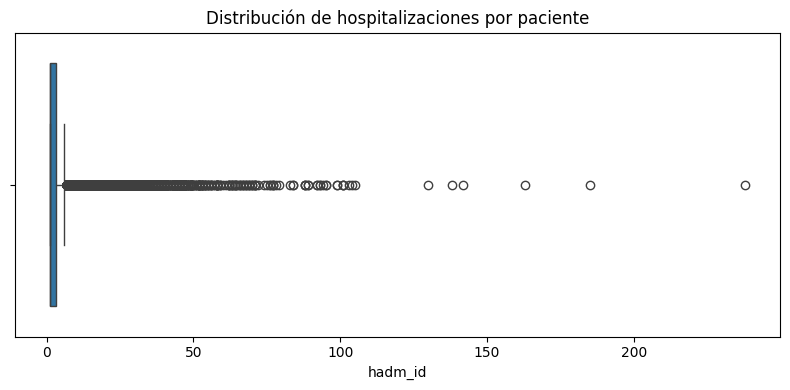

In [10]:
#Gráfico 3 — ver outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=admissions_per_patient)

plt.title("Distribución de hospitalizaciones por paciente")

plt.tight_layout()
plt.savefig("../results/eda_03_hospitalizaciones_por_paciente_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Análisis de las características de los pacientes

En esta sección se exploran algunas variables demográficas básicas de la tabla `patients`. Aunque se trata de un análisis preliminar, resulta útil para conocer el perfil general de la población incluida en el estudio.

### Edad

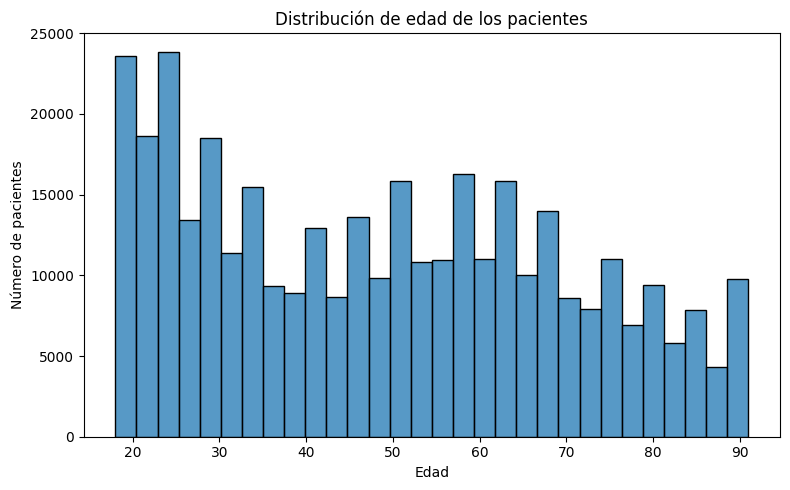

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(patients["anchor_age"], bins=30)

plt.title("Distribución de edad de los pacientes")
plt.xlabel("Edad")
plt.ylabel("Número de pacientes")

plt.tight_layout()
plt.savefig("../results/eda_04_distribucion_edad.png", dpi=150, bbox_inches="tight")
plt.show()

### Género

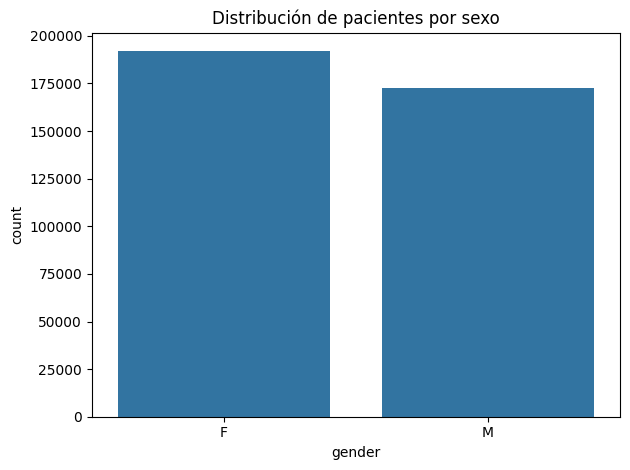

In [12]:
#Distribución de género
patients["gender"].value_counts()

sns.countplot(data=patients, x="gender")

plt.title("Distribución de pacientes por sexo")
plt.tight_layout()
plt.savefig("../results/eda_05_distribucion_genero.png", dpi=150, bbox_inches="tight")
plt.show()

La distribución demográfica observada ofrece una primera aproximación al perfil de los pacientes DEL dataset. Estas variables pueden resultar útiles como predictores, aunque su capacidad explicativa deberá evaluarse junto con el resto de la informacióN.

## 5. Análisis de las hospitalizaciones

La tabla `admissions` es una de las fuentes más importantes para este trabajo, ya que contiene información directamente relacionada con cada ingreso hospitalario. En este apartado se analizan variables asociadas a la duración de la estancia y al tipo de admisión.

In [13]:
#Duración de las hospitalizaciones
import pandas as pd 
admissions["admittime"] = pd.to_datetime(admissions["admittime"])
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"])

#Calculamos la duración de cada hospitalización en días
admissions["length_of_stay"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.days

print("Duración media de las hospitalizaciones (días):", admissions["length_of_stay"].mean())

Duración media de las hospitalizaciones (días): 4.221032621037749


**Gráfico 1.** Distribución general de la duración de las hospitalizaciones.

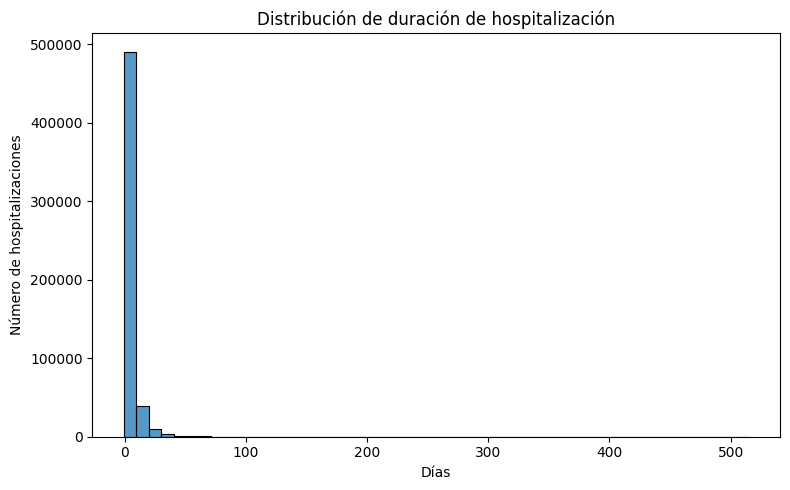

In [14]:
#Gráfico 1 general 
plt.figure(figsize=(8,5))

sns.histplot(admissions["length_of_stay"], bins=50)

plt.title("Distribución de duración de hospitalización")
plt.xlabel("Días")
plt.ylabel("Número de hospitalizaciones")

plt.tight_layout()
plt.savefig("../results/eda_06_duracion_hospitalizacion.png", dpi=150, bbox_inches="tight")
plt.show()

**Gráfico 2.** Distribución de la duración de las hospitalizaciones con mayor detalle en la zona central de los datos.

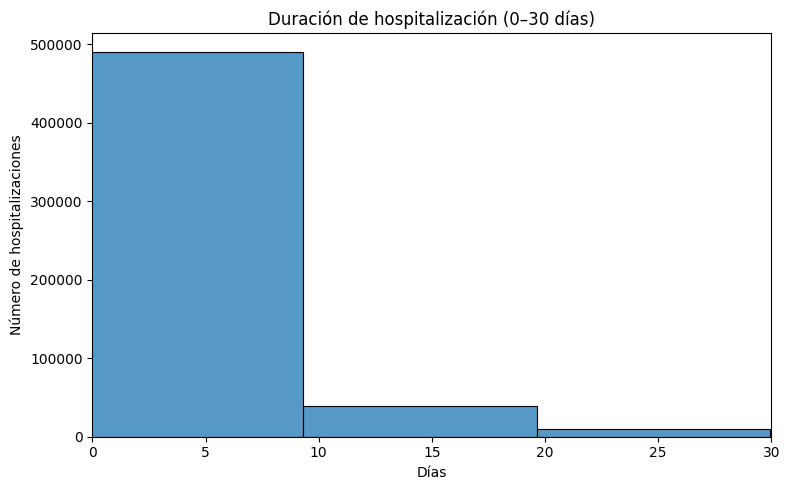

In [15]:
#2 grafico para verlo más en detalle 
plt.figure(figsize=(8,5))

sns.histplot(admissions["length_of_stay"], bins=50)

plt.xlim(0,30)

plt.title("Duración de hospitalización (0–30 días)")
plt.xlabel("Días")
plt.ylabel("Número de hospitalizaciones")

plt.tight_layout()
plt.savefig("../results/eda_07_duracion_hospitalizacion_detalle.png", dpi=150, bbox_inches="tight")
plt.show()

**Gráfico 3.** Boxplot para identificar valores atípicos en la duración de las hospitalizaciones.

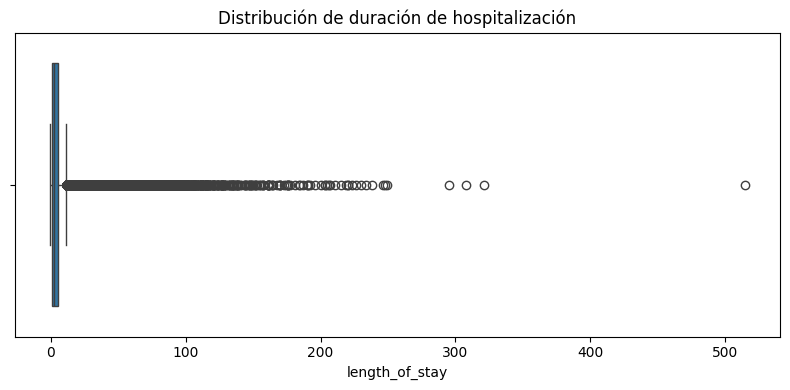

In [16]:
#Gráfico 3 — ver outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=admissions["length_of_stay"])

plt.title("Distribución de duración de hospitalización")

plt.tight_layout()
plt.savefig("../results/eda_08_duracion_hospitalizacion_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

La duración de la estancia presenta una concentración importante en ingresos de pocos días, junto con algunos casos extremos de hospitalizaciones prolongadas.

Este comportamiento sugiere una distribución asimétrica, algo habitual en variables clínicas de este tipo. 

### Tipo de admisión

In [ ]:
admissions["admission_type"].value_counts()

admission_type
EW EMER.                       177459
EU OBSERVATION                 119456
OBSERVATION ADMIT               84437
URGENT                          54929
SURGICAL SAME DAY ADMISSION     42898
DIRECT OBSERVATION              24551
DIRECT EMER.                    21973
ELECTIVE                        13130
AMBULATORY OBSERVATION           7195
Name: count, dtype: int64

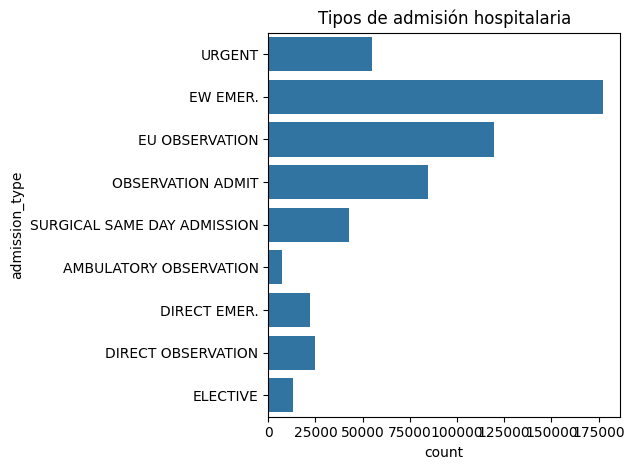

In [17]:
sns.countplot(y="admission_type", data=admissions)
plt.title("Tipos de admisión hospitalaria")
plt.tight_layout()
plt.savefig("../results/eda_09_tipos_admision.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Análisis clínico

Además de las variables demográficas y administrativas, el problema de readmisión está estrechamente relacionado con la información clínica del paciente. Por ello, en esta sección se revisan de forma tambien las tablas de diagnósticos, procedimientos y prescripciones más frecuentes.

La variable `admission_type` puede aportar más contexto, ya que no todas las admisiones responden al mismo nivel de urgencia ni presentan el mismo riesgo de evolución posterior. En fases posteriores convendrá valorar su codificación.

### Diagnósticos más frecuentes

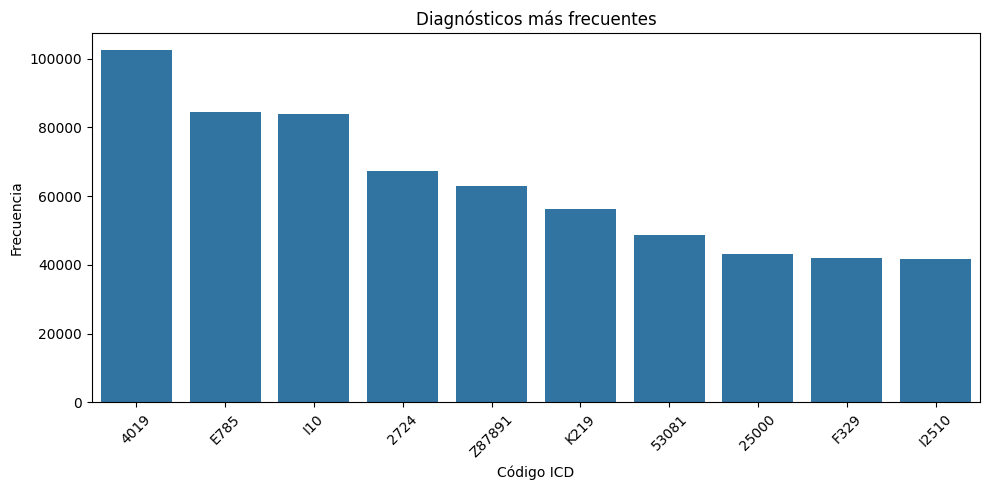

In [18]:
#Grafico para ver los diagnósticos más frecuentes   
top_diagnoses = diagnoses["icd_code"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_diagnoses.index, y=top_diagnoses.values)

plt.title("Diagnósticos más frecuentes")
plt.xlabel("Código ICD")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../results/eda_10_diagnosticos_frecuentes.png", dpi=150, bbox_inches="tight")
plt.show()

### Número de diagnósticos por hospitalización

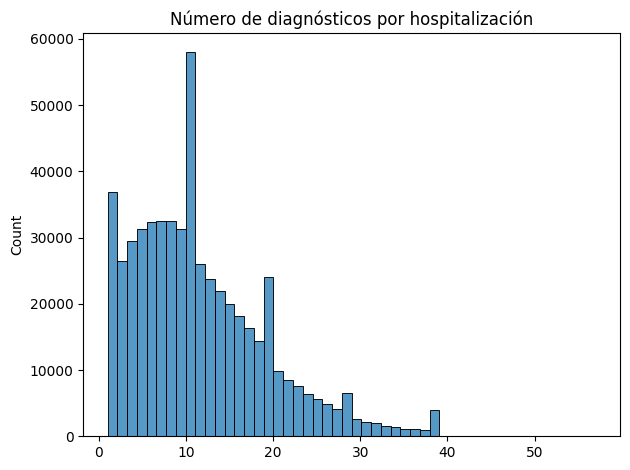

In [19]:
diagnoses_per_admission = diagnoses.groupby("hadm_id").size()

sns.histplot(diagnoses_per_admission, bins=50)
plt.title("Número de diagnósticos por hospitalización")
plt.tight_layout()
plt.savefig("../results/eda_11_diagnosticos_por_hospitalizacion.png", dpi=150, bbox_inches="tight")
plt.show()

### Procedimientos y prescripciones más frecuentes

In [ ]:
procedures["icd_code"].value_counts().head(10)


icd_code
3893       14644
02HV33Z    14353
8938       10519
3897       10347
8856        9549
3E0G76Z     8700
966         8165
3995        7808
0040        7581
9671        7382
Name: count, dtype: int64

In [ ]:
prescriptions["drug"].value_counts().head(10)

drug
Insulin                        21523
0.9% Sodium Chloride           18092
Sodium Chloride 0.9%  Flush    16484
Potassium Chloride             16436
Acetaminophen                  14359
Furosemide                     11155
Heparin                         9618
5% Dextrose                     9253
Magnesium Sulfate               9102
Bag                             8809
Name: count, dtype: int64

### Revisión de valores ausentes

La revisión de valores ausentes permite identificar qué variables podrían requerir imputación, eliminación o un tratamiento específico en la fase de preprocesado (siguiente fase).

In [ ]:
missing_values_admissions = admissions.isnull().sum().sort_values(ascending=False)
#print("Valores faltantes en admissions:\n", missing_values_admissions)

missing_values_patients = patients.isnull().sum().sort_values(ascending=False)
#print("Valores faltantes en patients:\n", missing_values_patients)

missing_values_diagnoses = diagnoses.isnull().sum().sort_values(ascending=False)
print("Valores faltantes en diagnoses:\n", missing_values_diagnoses)

missing_values_procedures = procedures.isnull().sum().sort_values(ascending=False)
print("Valores faltantes en procedures:\n", missing_values_procedures)

missing_values_prescriptions = prescriptions.isnull().sum().sort_values(ascending=False)
print("Valores faltantes en prescriptions:\n", missing_values_prescriptions)


Valores faltantes en diagnoses:
 subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64
Valores faltantes en procedures:
 subject_id     0
hadm_id        0
seq_num        0
chartdate      0
icd_code       0
icd_version    0
dtype: int64
Valores faltantes en prescriptions:
 form_rx              499319
doses_per_24_hrs     194497
gsn                   59662
poe_id                 4525
poe_seq                4525
order_provider_id      1541
ndc                     814
formulary_drug_cd       649
stoptime                553
starttime               384
dose_unit_rx            179
dose_val_rx             179
form_val_disp           179
form_unit_disp          179
prod_strength           179
route                   119
subject_id                0
hadm_id                   0
pharmacy_id               0
drug                      0
drug_type                 0
dtype: int64


Ver los valores nulos es importante de cara a saber que variables imputar o eliminar a priori se saca que por ejemplo algunas categoricas como `gender` o `race` no hace falta imputarlas pq no presentan nulos al contrario que `language` `ìnsurance` que sera necesario imputar. Al tratarse de categóricas no queremos perder información de cada paciente eliminandolas asi que lo se buscara es una imputación que aporte valor al modelo. En este caso se podría sustituir por `Unknown`

Este primer análisis deja claro que las tablas de diagnósticos, procedimientos y prescripciones contienen información potencialmente muy valiosa, pero también presentan una granularidad elevada. Sugiere que, para el modelado, probablemente será necesario agrupar categorías, seleccionar variables más representativas o construir características (feature engineering)

## 7. Conclusiones del EDA

A partir del EDA realizado pueden extraerse varias observaciones:

- La población estudiada presenta una alta concentración de pacientes con un único ingreso, aunque existe un subconjunto con múltiples hospitalizaciones, lo que refuerza el objetivo del trabajo.
- La duración de la estancia muestra una distribución claramente asimétrica, con predominio de ingresos cortos y presencia de valores extremos.
- Las variables clínicas, especialmente diagnósticos, procedimientos y fármacos, presentan una elevada riqueza informativa, pero también una alta cardinalidad, por lo que será necesario resumirlas o transformarlas adecuadamente en el preprocesado.
- El análisis de la calidad de datos demuestra la necesidad de revisar valores ausentes y decidir qué variables pueden aprovecharse sin introducir ruido ecesivo.

